In [126]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Load Aggregated Data from Database

In [127]:
engine = create_engine("sqlite:///nyc_rides.db")

df = pd.read_sql("SELECT * FROM hourly_demand", engine)

print("Modeling data shape:", df.shape)
df.head()

Modeling data shape: (748, 5)


,pickup_date,pickup_hour,pickup_day,is_weekend,ride_count
0,2024-12-31,20,1,0,3
1,2024-12-31,21,1,0,3
2,2024-12-31,23,1,0,15
3,2025-01-01,0,2,0,5675
4,2025-01-01,1,2,0,5509


## Prepare features for Linear Regression

In [138]:
X = df[["pickup_hour", "pickup_day"]]
y = df["ride_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Model

In [139]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate Model

In [140]:
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

RMSE: 1746.8198436987577


### visualize results

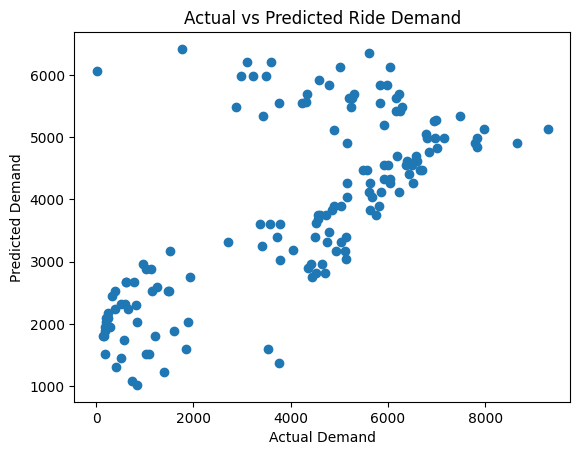

In [141]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Ride Demand")
plt.show()

## Prepare features for Random Forest

In [128]:
df["is_morning_peak"] = df["pickup_hour"].between(7, 9).astype(int)
df["is_evening_peak"] = df["pickup_hour"].between(16, 19).astype(int)

df.head()

,pickup_date,pickup_hour,pickup_day,is_weekend,ride_count,is_morning_peak,is_evening_peak
0,2024-12-31,20,1,0,3,0,0
1,2024-12-31,21,1,0,3,0,0
2,2024-12-31,23,1,0,15,0,0
3,2025-01-01,0,2,0,5675,0,0
4,2025-01-01,1,2,0,5509,0,0


In [129]:
df.columns

Index(['pickup_date', 'pickup_hour', 'pickup_day', 'is_weekend', 'ride_count',
       'is_morning_peak', 'is_evening_peak'],
      dtype='object')

### Prepare Features & Target

In [130]:
# If weekend column missing, recreate it safely
if "is_weekend" not in df.columns:
    df["is_weekend"] = df["pickup_day"].isin([5,6]).astype(int)

# Optional peak features (recommended)
df["is_morning_peak"] = df["pickup_hour"].between(7,9).astype(int)
df["is_evening_peak"] = df["pickup_hour"].between(16,19).astype(int)

# Feature matrix
X = df[
    [
        "pickup_hour",
        "pickup_day",
        "is_weekend",
        "is_morning_peak",
        "is_evening_peak"
    ]
]

# Target variable
y = df["ride_count"]

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Random Forest Model

In [132]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluate Model (Random Forest Model)

In [133]:
rf_predictions = rf_model.predict(X_test)

In [134]:
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print("Random Forest RMSE:", rmse)
print("Random Forest R2 Score:", r2)

Random Forest RMSE: 758.4988181567466
Random Forest R2 Score: 0.8986322203243254


### Visualization: Actual vs Predicted

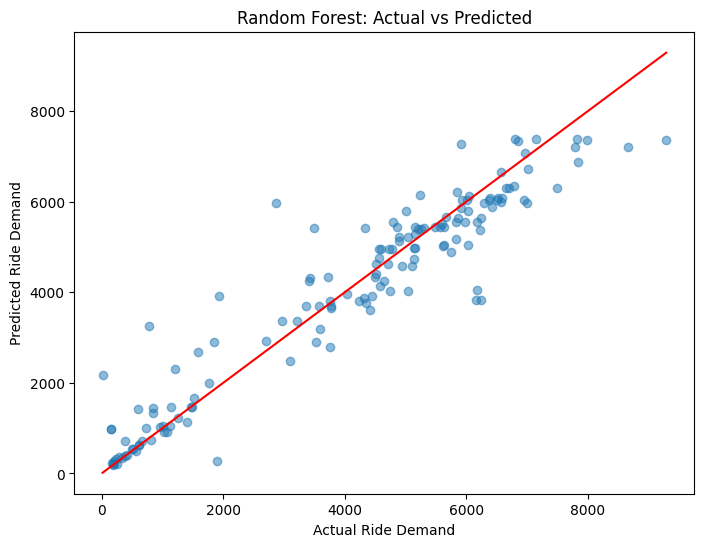

In [135]:
#Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_predictions, alpha=0.5)
plt.xlabel("Actual Ride Demand")
plt.ylabel("Predicted Ride Demand")
plt.title("Random Forest: Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()], color ='red'
)
plt.show()

### Visualization: Feature Importance

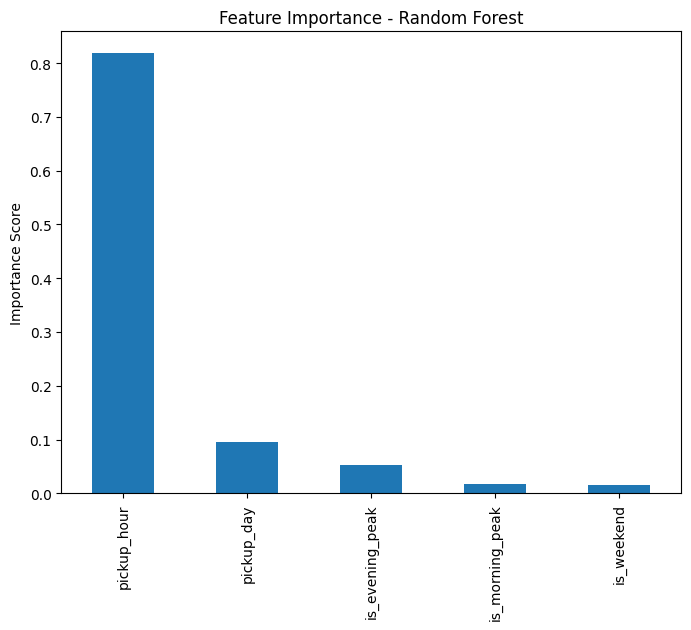

In [136]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

### Residual Analysis

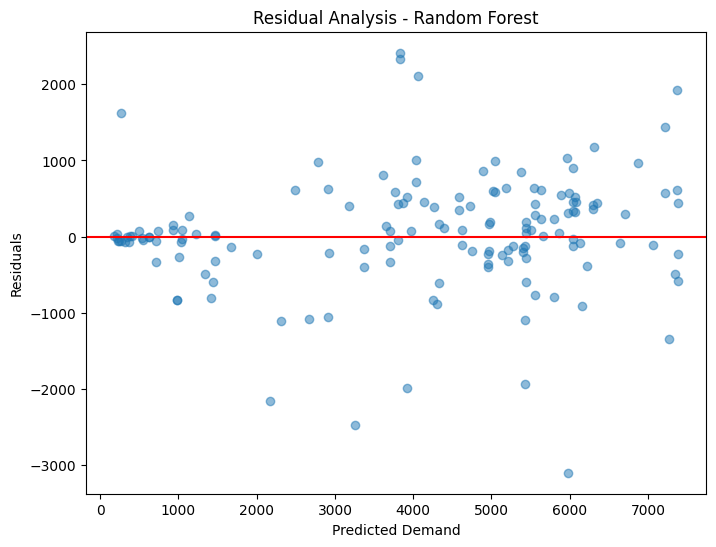

In [137]:
residuals = y_test - rf_predictions

plt.figure(figsize=(8,6))
plt.scatter(rf_predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Demand")
plt.ylabel("Residuals")
plt.title("Residual Analysis - Random Forest")
plt.show()